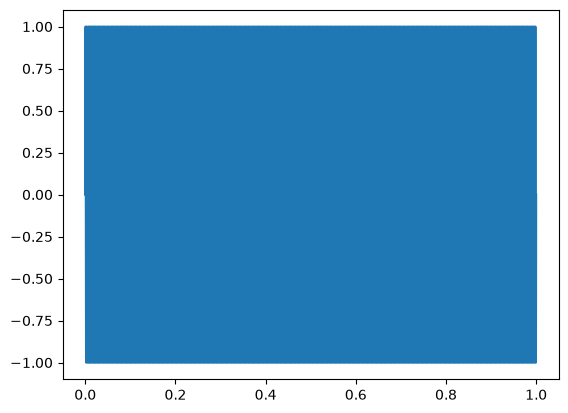

In [ ]:

import numpy as np
import matplotlib.pyplot as plt


from IPython.display import Audio,display
#from scipy.io import wavfile

RATE = 44_100
LA = 440
DO = 523.25

#2 Synthèse d'un son pur
#2.1 Génération d'une sinusoïde
#2.1.1 44100 (fréquence d'échantillonage)
#2.2.2 signal(t)=sin(2piϕt)
#2.2.3
def signal(f,t): 
    return np.sin(2*np.pi*f*t)

#affichage du son
t=np.linspace(0,1,44100)
son=signal(LA,t)
plt.plot(t,son)
plt.show()

#Ecoute du son
display(Audio(son,rate=RATE)) 


def display_signal(signal, rate=RATE, title="signal", width=1):
    display(Audio(signal,rate=RATE))
    
#2.2 Généralisation 
def sine(freq,duration=1,amplitude=1.):
    t=np.linspace(0,duration,duration*RATE)
    son=amplitude*np.sin(2*np.pi*freq*t)
    display(Audio(son,rate=RATE))

sine(DO,1,1)

#2.3
def sine_linear(freq1,freq2,duration):
    freq=np.linspace(freq1,freq2,duration*RATE)
    t=np.linspace(0,duration,duration*RATE)
    son=np.sin(2*np.pi*np.multiply(freq,t)) #ou avec integrale
    display(Audio(son,rate=RATE))
sine_linear(LA,DO,3)

#3 Gestion du volume et de la dynamique 
#3.1.1 en multipliant le son par une amplitude variant avec le temps
#3.1.2
def crescendo_sine(freq,duration):
    amplitude=np.linspace(0,1,duration*RATE)
    t=np.linspace(0,duration,duration*RATE)
    son=amplitude*np.sin(2*np.pi*t*freq)
    display(Audio(son,rate=RATE))
crescendo_sine(LA,2)
#3.1.3
def crescendo_sine2(freq,duration,increase=True):
    if increase:
        amplitude=np.linspace(0,1,duration*RATE)
    else:
        amplitude=np.linspace(1,0,duration*RATE)
    t=np.linspace(0,duration,duration*RATE)
    son=amplitude*np.sin(2*np.pi*t*freq)
    display(Audio(son,rate=RATE))
crescendo_sine2(LA,2,False)

#3.1.4
def crescendo_sine3(signal,duration,increase=True):
    if increase:
        amplitude=np.linspace(0,1,duration*RATE)
    else:
        amplitude=np.linspace(1,0,duration*RATE)
    t=np.linspace(0,duration,duration*RATE)
    son=amplitude*signal
    display(Audio(son,rate=RATE))

#4. Concaténation de sons
#Création d'une fonction générale pour la concaténation de 2 temps;)
def concatenation(freq1,freq2,dur1,dur2):
    t1=np.linspace(0,dur1,dur1*RATE)
    t2=np.linspace(dur1,dur1+dur2,dur2*RATE)
    son1=np.sin(2*np.pi*t1*freq1)
    son2=np.sin(2*np.pi*t2*freq2)
    son=np.concatenate((son1,son2),axis=0)
    display(Audio(son,rate=RATE))
concatenation(DO,LA,1,2)

#5. Formats de données audio
#5.1 Flottants vs entiers
#5.2 Représentation des entiers signés
